In [2]:
sentences = [
    # Cricket
    "Cricket is a widely loved outdoor sport played on a large grassy field.",
    "The game is played between two teams, each consisting of 11 players",
    "The main objective of the game is to score more runs than the opposing team",
    "Cricket is played in different formats, including Test matches, One Day Internationals, and T20 matches.",

    # Cooking
    "Boil noodles in salted water, immediately drain, and rinse with cold water to stop cooking.",
    "Saute garlic, ginger, and green chilies, then add shredded cabbage, sliced capsicum, carrots, and onions.",
    "Use soy sauce, red chili sauce, white vinegar, pepper, and tomato ketchup for the signature taste.",
    "Cook on high heat to get a slightly charred, crunchy texture, often with sesame oil for flavor.",

    # Cybersecurity
    "Strong passwords help protect accounts from hackers.",
    "Cybersecurity experts monitor networks for suspicious activity.",
    "Two-factor authentication adds an extra layer of security.",
    "Secure laptops, mobile devices, and computers with updated anti-malware software"
]

In [3]:
len(sentences)

12

**Import Libraries**

In [4]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

**Generate Embeddings**

In [5]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (12, 384)


**Cosine Similarity Matrix**

In [6]:
similarity_matrix = cosine_similarity(embeddings)

df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)

df

,Cricket is a widely loved outdoor sport played on a large grassy field.,"The game is played between two teams, each consisting of 11 players",The main objective of the game is to score more runs than the opposing team,"Cricket is played in different formats, including Test matches, One Day Internationals, and T20 matches.","Boil noodles in salted water, immediately drain, and rinse with cold water to stop cooking.","Saute garlic, ginger, and green chilies, then add shredded cabbage, sliced capsicum, carrots, and onions.","Use soy sauce, red chili sauce, white vinegar, pepper, and tomato ketchup for the signature taste.","Cook on high heat to get a slightly charred, crunchy texture, often with sesame oil for flavor.",Strong passwords help protect accounts from hackers.,Cybersecurity experts monitor networks for suspicious activity.,Two-factor authentication adds an extra layer of security.,"Secure laptops, mobile devices, and computers with updated anti-malware software"
Cricket is a widely loved outdoor sport played on a large grassy field.,1.000000,0.246090,0.338632,0.528658,-0.095567,-0.010420,-0.091465,0.054732,0.005936,0.004746,-0.012336,0.006461
"The game is played between two teams, each consisting of 11 players",0.246090,1.000000,0.489463,0.359690,-0.051660,0.062462,0.027680,-0.020416,-0.016907,0.028408,0.021879,-0.041575
The main objective of the game is to score more runs than the opposing team,0.338632,0.489463,1.000000,0.329415,-0.002856,0.060472,-0.024275,0.041792,0.099974,0.053971,0.098260,-0.051277
"Cricket is played in different formats, including Test matches, One Day Internationals, and T20 matches.",0.528658,0.359690,0.329415,1.000000,-0.092199,-0.009868,-0.045336,0.000459,-0.055286,0.021106,-0.038554,-0.015098
"Boil noodles in salted water, immediately drain, and rinse with cold water to stop cooking.",-0.095567,-0.051660,-0.002856,-0.092199,1.000000,0.316472,0.300015,0.390946,0.087240,-0.031279,-0.021717,0.089425
"Saute garlic, ginger, and green chilies, then add shredded cabbage, sliced capsicum, carrots, and onions.",-0.010420,0.062462,0.060472,-0.009868,0.316472,1.000000,0.505036,0.362094,-0.065667,-0.013588,-0.065251,-0.017164
"Use soy sauce, red chili sauce, white vinegar, pepper, and tomato ketchup for the signature taste.",-0.091465,0.027680,-0.024275,-0.045336,0.300015,0.505036,1.000000,0.466448,-0.036662,0.069784,-0.019376,-0.010541
"Cook on high heat to get a slightly charred, crunchy texture, often with sesame oil for flavor.",0.054732,-0.020416,0.041792,0.000459,0.390946,0.362094,0.466448,1.000000,0.044844,-0.013606,0.001756,-0.007698
Strong passwords help protect accounts from hackers.,0.005936,-0.016907,0.099974,-0.055286,0.087240,-0.065667,-0.036662,0.044844,1.000000,0.247910,0.457037,0.300587
Cybersecurity experts monitor networks for suspicious activity.,0.004746,0.028408,0.053971,0.021106,-0.031279,-0.013588,0.069784,-0.013606,0.247910,1.000000,0.193876,0.311346


**Heatmap Visualization**

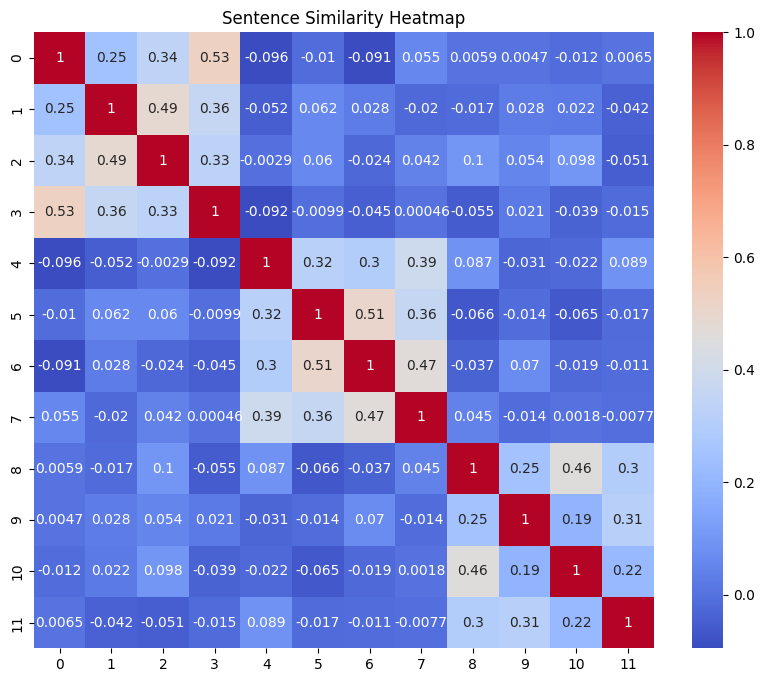

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, cmap="coolwarm")
plt.title("Sentence Similarity Heatmap")
plt.show()

**Query Sentence Similarity**

In [8]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

query_similarity = cosine_similarity(query_embedding, embeddings)[0]

similarity_scores = list(zip(sentences, query_similarity))

similarity_scores_sorted = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

top_2 = similarity_scores_sorted[:2]

for sentence, score in top_2:
    print(f"Sentence: {sentence}")
    print(f"Similarity Score: {score:.4f}")
    print()

Sentence: Cricket is played in different formats, including Test matches, One Day Internationals, and T20 matches.
Similarity Score: 0.3787

Sentence: Cricket is a widely loved outdoor sport played on a large grassy field.
Similarity Score: 0.3134

